In [75]:
from latent_dubins_ca_wm_pil import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class DubinEnv():
    def __init__(self, start_state, goal_state):
        self.start_state = start_state
        self.curr_state = start_state
        self.goal_state = goal_state
        self.args = get_args()
        self.v = self.args.speed
        self.dt = self.args.dt

    def forward(self, action):
        # Apply the action to the current state
        state_obs, img_obs, state_gt, dones, acs = ([] for _ in range(5))
        pstate = self.curr_state.copy()
        pstate[0] += self.v * np.cos(self.curr_state[2]) * self.dt
        pstate[1] += self.v * np.sin(self.curr_state[2]) * self.dt
        pstate[2] += action * self.dt  # Update the heading angle
        img = state_to_image_pil_hq(pstate, self.args)

        state_obs.append(pstate[2]) # get to observe theta
        state_gt.append(pstate) # gt state
        dones.append(1)
        acs.append(action)
        img_obs.append(img)

        demo = {}
        demo['obs'] = {'image': img_obs, 'state': state_obs, 'priv_state': state_gt}
        demo['actions'] = acs
        demo['dones'] = dones
        return demo, pstate
    
    def goal_ref(self):
        # Calculate the direction towards the goal
        dx = self.goal_state[0] - self.curr_state[0]
        dy = self.goal_state[1] - self.curr_state[1]
        angle_to_goal = np.arctan2(dy, dx)
        ref_theta = angle_to_goal
        delta_theta = ref_theta - self.curr_state[2]
        # Normalize the angle to be within [-pi, pi] using modulo operation
        # delta_theta = (delta_theta + np.pi) % (2 * np.pi) - np.pi
        ref_theta_dot = (delta_theta) / self.dt

        return ref_theta, np.clip(ref_theta_dot, -self.args.turnRate, self.args.turnRate)


Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 27002886 variables.
Step 1: Pstate: [-0.95  1.   -0.06], Goal: -0.79, Action: -1.25, Dist: 2.23
Step 2: Pstate: [-0.9   1.   -0.12], Goal: -0.8, Action: -1.25, Dist: 2.19
Step 3: Pstate: [-0.85  0.99 -0.19], Goal: -0.82, Action: -1.25, Dist: 2.15
Step 4: Pstate: [-0.8   0.98 -0.25], Goal: -0.83, Action: -1.25, Dist: 2.11
Step 5: Pstate: [-0.75  0.97 -0.31], Goal: -0.85, Action: -1.25, Dist: 2.07
Step 6: Pstate: [-0.71  0.95 -0.38], Goal: -0.86, Action: -1.25, Dist: 2.03
Step 7: Pstate: [-0.66  0.94 -0.44], Goal: -0.87, Action: -1.25, Dist: 1.99
Step 8: Pstate: [-0.61  0.91 -0.5 ], Goal: -0.88, Action: -1.25, Dist: 1.94
Step 9: Pstate: [-0.57  0.89 -0.56], Goal: -0.9, Action: -1.25, Dist: 1.89
Step 10: Pstate: [-0.53  0.86 -0.62], Goal: -0.91, Action: -1.25, Dist: 1.85
safe action engaged
Step 11

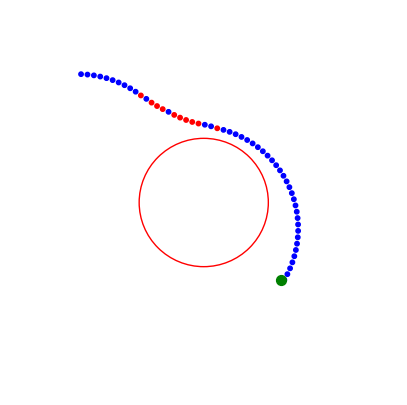

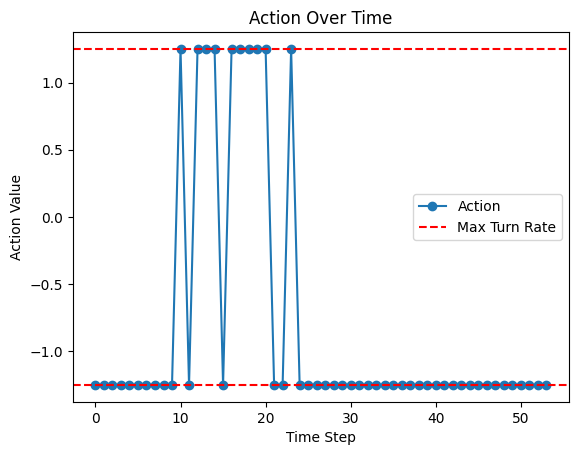

In [85]:
dubin_env = DubinEnv(start_state=np.array([-1.0, 1.0, 0.0]),
                     goal_state=0.6*np.array([1, -1, 0.0]))

# dubin_env = DubinEnv(start_state=np.array([-1.0, 1.0, 0.0]),
#                      goal_state=0.55*np.array([1, -1, 0.0]))
brt = LatentDubinContinuousAction()

pss = []
acs = []
css = []

eps = 0.1

for i in range(100):
    goal, ac_r = dubin_env.goal_ref()
    dem, ps = dubin_env.forward(0)
    val, lra = brt.obs_to_brt(dem)
    curr_safe = 1

    if val < eps:
        ac = lra[0]
        curr_safe = 0
        print('safe action engaged')
    else:
        ac = ac_r

    dem, ps = dubin_env.forward(ac)
    dubin_env.curr_state = ps  # Update the current state in the environment

    pss.append(ps)
    acs.append(ac)
    css.append(curr_safe)

    dist = np.linalg.norm(dubin_env.goal_state[:2] - dubin_env.curr_state[:2])
    print(f"Step {i+1}: Pstate: {np.round(ps,2)}, Goal: {np.round(goal,2)}, Action: {np.around(ac,2)}, Dist: {np.round(dist,2)}")

    if dist < 0.05:
        print("Reached the goal!")
        break

# plot the trajectory history and circle obstacle 
fig,ax = plt.subplots()
# hardcoded with existing limits
sf = 1
plt.xlim([sf*brt.args.x_min, sf*brt.args.x_max])
plt.ylim([sf*brt.args.y_min, sf*brt.args.y_max])
plt.axis('off')
fig.set_size_inches(5, 5)
pss = np.array(pss)
circle = patches.Circle((0,0), 0.5, edgecolor=(1,0,0), facecolor='none')
ax.add_patch(circle)
col = np.where(np.array(css) == 1, 'blue', 'red')
plt.scatter(pss[:,0], pss[:,1], c=col, s=10, label='Trajectory')
plt.scatter(dubin_env.goal_state[0], dubin_env.goal_state[1], c='green', s=50, label='Goal')

# plot action over time
plt.figure()
plt.plot(np.array(acs), label='Action', marker='o')
plt.axhline(y=dubin_env.args.turnRate, color='r', linestyle='--', label='Max Turn Rate')
plt.axhline(y=-dubin_env.args.turnRate, color='r', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Action Value')
plt.title('Action Over Time')
plt.legend()
plt.show()